<a href="https://colab.research.google.com/github/data602sps/assignments/blob/master/05_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 8**

# **Weeks 10 & 11- matplotlib & seaborn**
* In this homework assignment, you will explore and analyze a public dataset of your choosing. Since this assignment is “open-ended” in nature, you are free to expand upon the requirements below. However, you must meet the minimum requirments as indicated in each section.


* The preferred method for this analysis is in a .ipynb file. Feel free to use whichever platform of your choosing.  


### **Some data examples:**
•	https://www.data.gov/

•	https://opendata.cityofnewyork.us/

•	https://datasetsearch.research.google.com/

•	https://archive.ics.uci.edu/ml/index.php

### **Resources:**

•	https://pandas.pydata.org/pandas-docs/stable/getting_started/10min.html

•	https://www.oreilly.com/library/view/python-data-science/9781491912126/ch04.html

•	https://www.data-to-viz.com/



### **Headings or comments**
**You are required to make use of comments, or headings for each section.  You must explain what your code is doing, and the results of running your code.**  Act as if you were giving this assignment to your manager - you must include clear and descriptive information for each section.

### **You may work as a group or indivdually on this assignment.**


# Introduction

In this section, please describe the dataset you are using.  Include a link to the source of this data.  You should also provide some explanation on why you choose this dataset.

The data source I'll be using for this assignment, a .CSV file, was downloaded from the United Nations Office on Drugs and Crime (UNDOC) website: https://dataunodc.un.org/dp-trafficking-persons This data was collected by using the Questionnaire for the Global Report on Trafficking in Persons (GLOTIP), hence the name of the original file being "data_glotip".
I'm choosing this dataset because human trafficking is a pervasive crime that ensnares people of every age, gender, and background in forced labor, commercial sex, and other formats alike to modern slavery. Today, it’s estimated that 27.6 million individuals suffer under trafficking conditions. I explore this dataset due to the seriousness this data reflects on the real world.

______________
# Data Exploration
Import your dataset into your .ipynb, create dataframes, and explore your data.  

Include:

* Summary statistics means, medians, quartiles,
* Missing value information
* Any other relevant information about the dataset.  



In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/GullitNa/DATA602Week8/main/data_glotip.csv"
df = pd.read_csv(url, skiprows=2, dtype=str, encoding="latin1")

df.head()

df.info()

df['txtVALUE'] = (
    df['txtVALUE']
    .str.replace(",", "")
    .pipe(pd.to_numeric, errors='coerce')
)
df['txtVALUE'].describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58769 entries, 0 to 58768
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Iso3_code            58743 non-null  object
 1   Country              58769 non-null  object
 2   Region               58769 non-null  object
 3   Subregion            58769 non-null  object
 4   Indicator            58769 non-null  object
 5   Dimension            58769 non-null  object
 6   Category             58649 non-null  object
 7   Sex                  58769 non-null  object
 8   Age                  58769 non-null  object
 9   Year                 58769 non-null  object
 10  Unit of measurement  58769 non-null  object
 11  txtVALUE             58769 non-null  object
 12  Source               58769 non-null  object
dtypes: object(13)
memory usage: 5.8+ MB


,0
Iso3_code,26
Country,0
Region,0
Subregion,0
Indicator,0
Dimension,0
Category,120
Sex,0
Age,0
Year,0


# Data Wrangling

Perform data wrangling.  You are free to use your best judgment here.  If you are stuck, look at previous assignment.

In [4]:
df = (
    df.rename(columns={
        'Iso3_code': 'Abbreviation',
        'txtVALUE': 'Count',
        'Unit of measurement': 'Unit_of_measurement'
    })
    .drop(columns=['Unit_of_measurement'])
)

# Change back NA to count as 2 instead as that's the midpoint (better than throwing that data away)
df['Count'] = df['Count'].fillna(2).astype(int)

# Keep only detected trafficking victims
df = df[df['Indicator'] == 'Detected trafficking victims']
df.head()

,Abbreviation,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Count,Source
0,ABW,Aruba,Americas,Latin America and the Caribbean,Detected trafficking victims,by country of repatriation,Ukraine,Total,Total,2010,2,GLOTIP
1,AFG,Afghanistan,Asia,Southern Asia,Detected trafficking victims,by country of repatriation,Abroad,Total,Total,2003,2,GLOTIP
2,AFG,Afghanistan,Asia,Southern Asia,Detected trafficking victims,by country of repatriation,Abroad,Total,Total,2008,2,GLOTIP
5,AFG,Afghanistan,Asia,Southern Asia,Detected trafficking victims,by form of exploitation,Sexual exploitation,Total,Total,2017,2,GLOTIP
6,AFG,Afghanistan,Asia,Southern Asia,Detected trafficking victims,by form of exploitation,Forced labour,Total,Total,2018,2,GLOTIP


# Visualizations

The main purpose of this assignment is to practice creating various visualizations using the matplotlib and seaborn library.

### **Part 1:**
Using matplotlib, create ***two or more plots*** that incorporate at least **5** of the following properties:

Note: these properties vary based on your data.  The goal is to practice creating visualizations and modifying its properties.

*   Use and change a legend position
*   Change a legend font size
*   Place a legend outside of the plot
*   Create a single legend for all subplots
*   Change the title and x/y labels
*   Change the marker, line colors, and line width
*   Add annotations
*   Modify Axis Text Ticks/Labels
*   Change size of axis Labels
*   Your own choice not included above


Plots that you can create **include**:

*   Scatter Plot
*   Bar plot
*   Line Chart
*   Multi Plots (e.g. using .subplot()
*   Histogram

You can add another plot not listed here if it works better for your data.  This is not a complete list of plots to create.

### **Part 2:**

Recreate the visualizations above using the Seaborn library as best as possible.  


**You are required to explain what each of your plots is representing. Plots without comments will not be accepted.**  In addition, please explain the properties you are showcasing.


### **Part 3:**
In a comment or text box, explain the differences between creating a plot in matplotlib and seaborn, based on your above plots.



**Part 1: First series of plots will be the trend of human trafficking victims by gender. Import the necessary packages before plotting for both matlib and seaborn in next plot and here filter out to "total" records from the dataset. Followed by converting year into numeric. Based on the plot shown below: The trend of victims by gender shows that females are consistently more often human trafficking victims than males every year. What will be done is 1. Use and change a legend position 2. Change the marker, line colors, and line width 3. Add annotations 4. Modify Axis Text Ticks/Labels 5. Change size of axis Labels in the form of 2 plots (matlib shown here)**

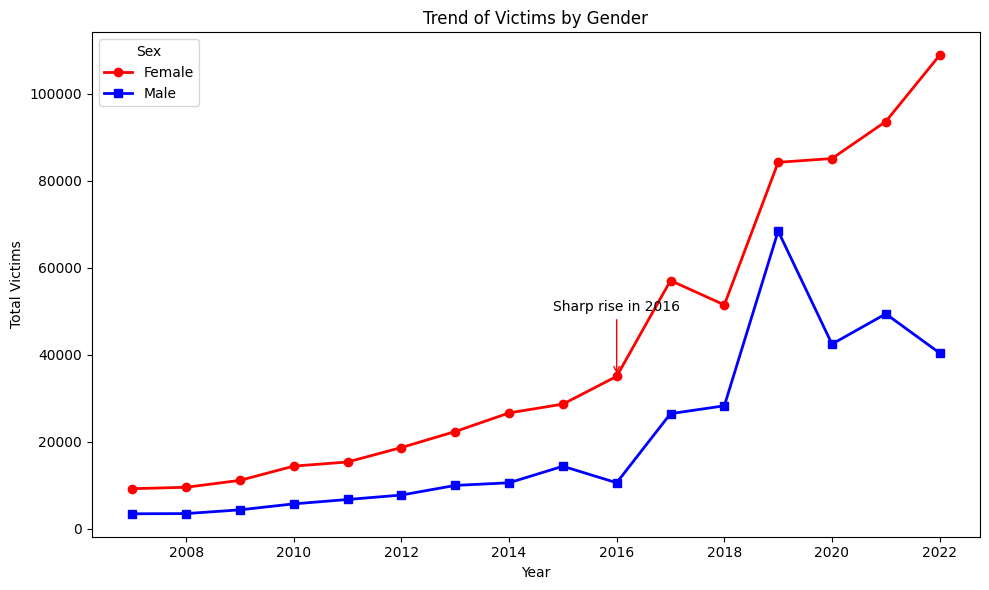

In [26]:
import matplotlib.pyplot as plt
markers = {'Female':'o', 'Male':'s'}

tot = df[(df.Dimension == 'Total') & (df.Category == 'Total')].copy()
tot.loc[:, 'Year'] = pd.to_numeric(tot['Year'], errors='coerce')

gender_trend = (
    tot
    .groupby(['Year','Sex'])['Count']
    .sum()
    .unstack()
)
fig, ax = plt.subplots(figsize=(10,6))

for sex in ["Female","Male"]:
    ax.plot(
        gender_trend.index,
        gender_trend[sex],
        marker=markers[sex],
        color=colors[sex],
        linewidth=2,
        label=sex
    )

y2016 = gender_trend.loc[2016, "Female"]
ax.annotate(
    "Sharp rise in 2016",
    xy=(2016, y2016),
    xytext=(2016, y2016 + 15000),
    ha="center",
    arrowprops=dict(arrowstyle="->", color=colors["Female"])
)
ax.set_title("Trend of Victims by Gender")
ax.set_xlabel("Year")
ax.set_ylabel("Total Victims")
ax.legend(title="Sex", loc="upper left")

plt.tight_layout()
plt.show()

**Part 2:** I'll translate what I've plotted from the matlib package into seaborn.

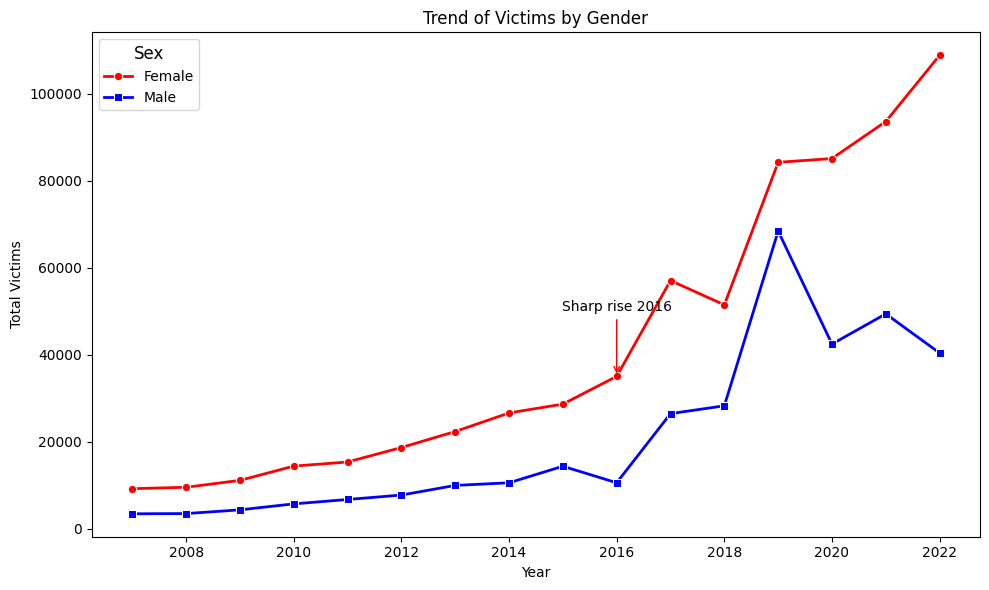

In [27]:
import seaborn as sns

gender_trend = (
    tot
    .groupby(['Year','Sex'])['Count']
    .sum()
    .unstack()
    .loc[:, ["Female","Male"]]
)
gender_trend = (
    tot
    .groupby(['Year','Sex'])['Count']
    .sum()
    .unstack()
    .loc[:, ["Female","Male"]]
)
df_gender = (
    gender_trend
    .reset_index()
    .melt(
      id_vars="Year",
      value_vars=["Female","Male"],
      var_name="Sex",
      value_name="Victims"
    )
)
plt.figure(figsize=(10,6))
ax = sns.lineplot(
    data=df_gender,
    x="Year",
    y="Victims",
    hue="Sex",
    style="Sex",
    markers={"Female": "o", "Male": "s"},
    dashes=False,
    linewidth=2,
    palette={"Female":"red", "Male":"blue"}
)

y2016 = gender_trend.loc[2016, "Female"]
ax.annotate(
    "Sharp rise 2016",
    xy=(2016, y2016),
    xytext=(2016, y2016 + 15000),
    ha="center",
    arrowprops=dict(arrowstyle="->", color="red")
)

ax.set_title("Trend of Victims by Gender")
ax.set_xlabel("Year")
ax.set_ylabel("Total Victims")
ax.legend(title="Sex", loc="upper left", fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

**PART 3:** All the series of plots shown here, the clear differences between the two are: Matlib needed me to manually group and pivot our "df" while with seaborn I used melt() to turn it back into “long” form and let sns.lineplot() handle the splitting by hue="Sex" and style="Sex" automatically. Additionally, In Matplotlib I can say “for each sex, plot X vs Y with marker/color/linewidth/label. But in seaborn I only have to code it once and it draws both lines for you in one call.

# Conclusions  

After exploring your dataset, provide a short summary of what you noticed from this dataset.  

Based on the findings of the dataset, I foudn that the female sex is far more likely to be victims of human trafficking than their male counterparts. In fact, the plots both show that consistently every year females are targeted more than males.